# Tutorial 10 · Lagrange Multipliers & KKT — Part B

**~40 minutes · after the worksheet**

Solve equality and inequality constrained problems, then verify every KKT condition numerically.

Work in pairs. Before each code cell, write down the qualitative result you expect. The notebook is designed to run top-to-bottom in a fresh kernel.


## 1 · Contours meeting a constraint


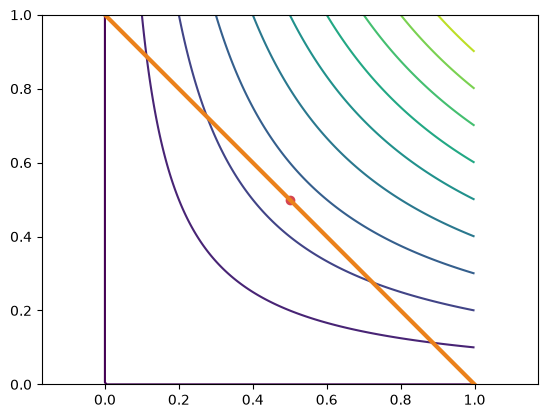

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(0,1,200); X,Y=np.meshgrid(x,x)
plt.contour(X,Y,X*Y,levels=10); plt.plot(x,1-x,color="#EB811B",lw=3)
plt.scatter([.5],[.5],color="#D64550"); plt.axis("equal");


## 2 · Verify KKT residuals


In [2]:
x, lam = 1.0, 2.0
checks={
    "primal g(x)<=0": x-1,
    "dual lambda>=0": lam,
    "stationarity": 2*(x-2)+lam,
    "complementarity": lam*(x-1),
}
print(checks)


{'primal g(x)<=0': 0.0, 'dual lambda>=0': 2.0, 'stationarity': 0.0, 'complementarity': 0.0}


## 3 · Project onto the simplex by thresholding


In [3]:
def project_simplex(a, budget):
    lo, hi = 0.0, np.max(a)
    for _ in range(80):
        nu=(lo+hi)/2
        if np.maximum(a-nu,0).sum()>budget: lo=nu
        else: hi=nu
    return np.maximum(a-hi,0), hi
x,nu=project_simplex(np.array([3.,1.,.5]),2.5)
print(x,"threshold",nu,"sum",x.sum())


[2.25 0.25 0.  ] threshold 0.7499999999999998 sum 2.5


## Closing check

Write three sentences: one numerical result you verified, one geometric/probabilistic interpretation, and one failure mode you would now test in a larger implementation.
